In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math as mm
import opstool as opst
import time as tt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (149475865274)>


In [5]:
#==============================================================================
#Input Variables
'''
nDMaterial('PM4Sand', matTag, Dr, G0, hpo, rho, P_atm, h0, e_max, e_min, 
           nb, nd, Ado, z_max, c_z, c_e, phi_cv, nu, g_degr, c_dr, c_kaf, 
           Q, R, m_par, F_sed, p_sed)
'''
atm = -101.325
sig_v0 = 2.0* atm #initial vertical stress
CSR = 0.2 #cyclic stress ratio
Cycle_max = 5 #maximxum number of cycles
strain_in = 5.0e-6 #strain increment
K0 = 0.5
nu = K0/(1+K0) #poisson's ratio
devDisp = 0.03 #cutoff shear strain
perm = 1e-9 #permeability
#==============================================================================

#primary parameters
Dr = 0.5
G0 = 476.0
hpo = 0.53 #Contraction rate parameter
rho = 1.42 #mass density, KN/m3

#secondary parameters
P_atm = 101.325
# all initial stress dependant parameters have negative default values 
# and will be calculated during initialization
h0 = -1.0  #Variable that adjusts the ratio of plastic modulus to elastic modulus
e_max = 0.8
e_min = 0.5
e_ini = e_max - (e_max - e_min)*Dr #initial void ratio
nb = 0.5 #Bounding surface parameter, nb>=0
nd = 0.1 #Dilatancy surface parameter, nd>=0
Ado = -1.0
#Dilatancy parameter, will be computed at the time of initialization if input value is negative
z_max = -1.0 #Fabric-dilatancy tensor parameter
c_z = 250.0 #Fabric-dilatancy tensor parameter
c_e = -1.0 #Fabric-dilatancy tensor parameter
phi_cv = 26.0 #Critical state effective friction angle
g_degr = 2.0 #Variable that adjusts degradation of elastic modulus with accumulation of fabric
c_dr = -1.0 #Variable that controls the rotated dilatancy surface
c_kaf = -1.0 # Variable that controls the effect that sustained static shear stresses have on plastic modulus
Q = 10.0 #Critical state line parameter
R = 1.5 #Critical state line parameter
m_par = 0.01#Yield surface constant
F_sed = -1.0#Variable that controls the minimum value the reduction factor of the elastic moduli can get during reconsolidation
p_sed = -1.0#Mean effective stress up to which reconsolidation strains are enhanced

#%%
#Rayleigh Damping Parameters
'''
rayleigh(alphaM, betaK, betaKinit, betaKcomm)
'''
damp = 0.02
omega1 = 0.2
omega2 = 20.0
a1 = 2.0*damp/(omega1+omega2) #a1 is alphaM
a0 = a1*omega1*omega2 #a0 is betaK
#%%
#create model
#Remove the existing model, important!!! 
ops.wipe()

# set modelbuilder
ops.model('basic', '-ndm', 2, '-ndf', 3)

#model nodes
x1 = 0.0
y1 = 0.0

x2 = 1.0
y2 = 0.0

x3 = 1.0
y3 = 1.0

x4 = 0.0
y4 = 1.0

#create nodes

ops.node(1, x1, y1)
ops.node(2, x2, y2)
ops.node(3, x3, y3)
ops.node(4, x4, y4)

#boundary conditions
ops.fix(1, 1, 1, 1)
ops.fix(2, 1, 1, 1)
ops.fix(3, 0, 0, 1)
ops.fix(4, 0, 0, 1)
ops.equalDOF(3,4,1,2) #make node 3 and 4 equal displacement at degrees 1 & 2

#material
#==================================================================
#nDMaterial('PM4Sand', matTag, D_r, G_o, h_po, Den, P_atm, h_o, e_max, 
#e_min, n_b, n_d, A_do, z_max, c_z, c_e, phi_cv, nu, g_degr, c_dr, c_kaf, 
#Q_bolt, R_bolt, m_par, F_sed, p_sed)
#==================================================================
# ops.nDMaterial('PM4Sand', 1, Dr, G0, hpo, rho, P_atm, h0, e_max, e_min, 
#            nb, nd, Ado, z_max, c_z, c_e, phi_cv, nu, g_degr, c_dr, c_kaf, 
#            Q, R, m_par, F_sed, p_sed)

ops.nDMaterial('DruckerPrager', 2, 27777.78, 9259.26, 5.0, 0.398, 0.398, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.7) # 9259.26

#element
ops.element('SSPquadUP',1, 1,2,3,4, 2, 1.0, 2.2e6, 1.0, perm, perm, e_ini, 1.0e-5)

#create recorders
ops.recorder('Node','-file', 'Cycdisp.txt','-time', '-node',1,2,3,4,'-dof', 1, 2, 'disp')
ops.recorder('Node','-file', 'CycPP.txt','-time', '-node',1,2,3,4,'-dof', 3, 'vel')
ops.recorder('Element','-file', 'Cycstress.txt','-time','-ele', 1, 'stress')
ops.recorder('Element','-file', 'Cycstrain.txt','-time','-ele', 1, 'strain')
#%%
#Analysis officially starts here
ops.constraints('Transformation')
ops.test('NormDispIncr', 1.0e-5, 35, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('FullGeneral')
ops.integrator('Newmark', 5.0/6.0, 4.0/9.0)
ops.rayleigh(a1, a0, 0.0, 0.0) #modification
ops.analysis('Transient')

#%%apply consolidation pressure
pNode = sig_v0/2.0 #put confining pressure evenly on two nodes

# create a plain load pattern with time series 1
ops.timeSeries('Path', 1, '-values', 0, 1, 1, '-time', 0.0, 100.0, 1.0e10)
ops.pattern("Plain", 1, 1, '-factor',1.0)
ops.load(3, 0.0, pNode, 0.0) #apply vertical pressure at y direction
ops.load(4, 0.0, pNode, 0.0)
ops.updateMaterialStage('-material', 1, '-stage', 0)
ops.analyze(100,1.0)
vDisp = ops.nodeDisp(3,2)
b = ops.eleResponse(1, 'stress') #b = [sigmaxx, sigmayy, sigmaxy]
print('shear stress is',b[2])
ops.timeSeries('Path', 2, '-values', 1.0, 1.0, 1.0, '-time', 100.0, 80000.0, 1.0e10, '-factor', 1.0)
ops.pattern('Plain', 2, 2,'-factor',1.0)
ops.sp(3, 2, vDisp)
ops.sp(4, 2, vDisp)

#Close Drainage
for i in range(4):
    ops.remove('sp', i+1, 3)
    print('Node ID', i+1)


ops.analyze(25,1.0)
b = ops.eleResponse(1, 'stress') #b = [sigmaxx, sigmayy, sigmaxy]
print('shear stress is',b[2])
print('Drainage is closed')

ops.updateMaterialStage('-material', 1, '-stage', 1)
'''
Note:
The program will use the default value of a secondary parameter if 
a negative input is assigned to that parameter, e.g. Ado = -1. 
However, FirstCall is mandatory when switching from elastic to elastoplastic 
if negative inputs are assigned to stress-dependent secondary parameters, 
e.g. Ado and zmax. 
'''

#setParameter('-value', 0, '-ele', elementTag, 'FirstCall', matTag)
ops.setParameter('-val', 0, '-ele', 1, 'FirstCall', '1')

ops.analyze(25,1.0)
b = ops.eleResponse(1, 'stress') #b = [sigmaxx, sigmayy, sigmaxy]
print('shear stress is',b[2])
print('finished update fixties')
# update Poisson's ratio for analysis
#setParameter -value 0.3 -ele 1 poissonRatio 1
ops.setParameter('-val', 0.3, '-ele',1, 'poissonRatio', '1')

shear stress is 0.0
Node ID 1
Node ID 2
Node ID 3
Node ID 4
shear stress is 2.891206024591142e-13
Drainage is closed
shear stress is -3.8147857268910904e-13
finished update fixties


DruckerPrager nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington
SSPquadUP element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
CTestNormDispIncr::test() - iteration: 1 current Norm: 4.97651e-05 (max: 1e-05, Norm R: 0)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.1083e-05 (max: 1e-05, Norm R: 0)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.0126e-05 (max: 1e-05, Norm R: 0)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.07368e-05 (max: 1e-05, Norm R: 1.77636e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.36223e-20 (max: 1e-05, Norm R: 1.77636e-15)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.03752e-05 (max: 1e-05, Norm R: 1.77636e-15)
CTe

In [6]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [7]:
# Initialize ODB for response tracking
ODB = opst.post.CreateODB(
    odb_tag=1,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)

controlDisp = 1.1 * devDisp
numCycle = 0.25
print('Current Number of Cycle:', numCycle)

start = tt.time()
numCycle = 0.0

while numCycle <= Cycle_max:
    hDisp = ops.nodeDisp(3, 1)
    cur_time = ops.getTime()

    # 1/4 cycle: zero to +max stress
    steps = controlDisp / strain_in
    time_change = cur_time + steps
    ops.timeSeries("Path", 3, "-values", hDisp, controlDisp, controlDisp,
                   "-time", cur_time, time_change, 1.0e10, "-factor", 1.0)
    ops.pattern("Plain", 3, 3, "-fact", 1.0)
    ops.sp(3, 1, 1.0)

    b = ops.eleResponse(1, 'stress')
    print('shear stress is', b[2])

    while b[2] <= CSR * sig_v0 * -1.0:
        ops.analyze(1, 1.0)
        b = ops.eleResponse(1, 'stress')
        ODB.fetch_response_step()
        hDisp = ops.nodeDisp(3, 1)
        if hDisp >= devDisp:
            print('loading break')
            break

    numCycle += 0.25
    hDisp = ops.nodeDisp(3, 1)
    cur_time = ops.getTime()

    # Clean up
    ops.remove('loadPattern', 3)
    ops.remove('timeSeries', 3)
    ops.remove('sp', 3, 1)

    # 1/2 cycle: +max to -max
    steps = (controlDisp + hDisp) / strain_in
    time_change = cur_time + steps
    ops.timeSeries("Path", 3, "-values", hDisp, -controlDisp, -controlDisp,
                   "-time", cur_time, time_change, 1.0e10, "-factor", 1.0)
    ops.pattern("Plain", 3, 3)
    ops.sp(3, 1, 1.0)

    while b[2] > CSR * sig_v0:
        ops.analyze(1, 1.0)
        b = ops.eleResponse(1, 'stress')
        ODB.fetch_response_step()
        print('shear stress is', b[2])
        hDisp = ops.nodeDisp(3, 1)
        if hDisp <= -devDisp:
            print('unloading break')
            break

    numCycle += 0.5
    hDisp = ops.nodeDisp(3, 1)
    cur_time = ops.getTime()

    # Clean up
    ops.remove('loadPattern', 3)
    ops.remove('timeSeries', 3)
    ops.remove('sp', 3, 1)

    # Final 1/4 cycle: back to zero stress
    steps = (controlDisp + hDisp) / strain_in
    time_change = cur_time + steps
    ops.timeSeries("Path", 3, "-values", hDisp, controlDisp, controlDisp,
                   "-time", cur_time, time_change, 1.0e10, "-factor", 1.0)
    ops.pattern("Plain", 3, 3, "-fact", 1.0)
    ops.sp(3, 1, 1.0)

    while b[2] <= 0.0:
        ops.analyze(1, 1.0)
        b = ops.eleResponse(1, 'stress')
        ODB.fetch_response_step()
        print('shear stress is', b[2])
        hDisp = ops.nodeDisp(3, 1)
        if hDisp >= devDisp:
            print('reloading break')
            break

    numCycle += 0.25
    print('Current Number of Cycle:', numCycle)
    ops.remove('loadPattern', 3)
    ops.remove('timeSeries', 3)

ODB.save_response(zlib=True)
print("ODB response saved")


Current Number of Cycle: 0.25
shear stress is -3.8147857268910904e-13


CTestNormDispIncr::test() - iteration: 1 current Norm: 40155.2 (max: 1e-05, Norm R: 2.79644e-17)
CTestNormDispIncr::test() - iteration: 2 current Norm: 5.56497e-10 (max: 1e-05, Norm R: 2.49219e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 40953 (max: 1e-05, Norm R: 5.49497e-17)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.09356e-09 (max: 1e-05, Norm R: 2.505e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 41750.8 (max: 1e-05, Norm R: 2.81592e-18)
CTestNormDispIncr::test() - iteration: 2 current Norm: 5.60262e-11 (max: 1e-05, Norm R: 3.64229e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 42548.6 (max: 1e-05, Norm R: 1.03522e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.00313e-10 (max: 1e-05, Norm R: 9.39633e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 43346.4 (max: 1e-05, Norm R: 1.04312e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 3.24623e-10 (max: 1e-05, Norm R: 7.24041e-19)

CTestNorm

shear stress is 40.439818049999346
shear stress is 40.39352174999935
shear stress is 40.34722544999934
shear stress is 40.30092914999935
shear stress is 40.254632849999346
shear stress is 40.20833654999935
shear stress is 40.162040249999336
shear stress is 40.11574394999935
shear stress is 40.06944764999935
shear stress is 40.02315134999935
shear stress is 39.976855049999344
shear stress is 39.93055874999934
shear stress is 39.88426244999935
shear stress is 39.837966149999346
shear stress is 39.79166984999934
shear stress is 39.74537354999934
shear stress is 39.69907724999935
shear stress is 39.65278094999935
shear stress is 39.60648464999935
shear stress is 39.56018834999934
shear stress is 39.51389204999935
shear stress is 39.46759574999935
shear stress is 39.42129944999935
shear stress is 39.37500314999934
shear stress is 39.32870684999935
shear stress is 39.28241054999935
shear stress is 39.23611424999935
shear stress is 39.189817949999345
shear stress is 39.14352164999934
shear st

CTestNormDispIncr::test() - iteration: 1 current Norm: 816401 (max: 1e-05, Norm R: 1.08979e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.16618e-09 (max: 1e-05, Norm R: 3.0666e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 817199 (max: 1e-05, Norm R: 6.46131e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.28585e-08 (max: 1e-05, Norm R: 9.1998e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 817997 (max: 1e-05, Norm R: 6.86476e-17)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.3613e-09 (max: 1e-05, Norm R: 9.19976e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 818795 (max: 1e-05, Norm R: 7.88453e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.56908e-08 (max: 1e-05, Norm R: 3.0666e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 819592 (max: 1e-05, Norm R: 2.51767e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 5.01042e-09 (max: 1e-05, Norm R: 3.0666e-19)

CTestNormDispIn

shear stress is 33.912039749999344
shear stress is 33.86574344999935
shear stress is 33.81944714999935
shear stress is 33.77315084999935
shear stress is 33.72685454999934
shear stress is 33.68055824999935
shear stress is 33.63426194999934
shear stress is 33.58796564999935
shear stress is 33.541669349999346
shear stress is 33.495373049999344
shear stress is 33.44907674999934
shear stress is 33.40278044999935
shear stress is 33.356484149999346
shear stress is 33.310187849999345
shear stress is 33.26389154999934
shear stress is 33.21759524999935
shear stress is 33.17129894999935
shear stress is 33.125002649999345
shear stress is 33.07870634999935
shear stress is 33.03241004999934
shear stress is 32.98611374999935
shear stress is 32.93981744999934
shear stress is 32.893521149999344
shear stress is 32.84722484999934
shear stress is 32.80092854999935
shear stress is 32.75463224999934
shear stress is 32.708335949999345
shear stress is 32.66203964999934
shear stress is 32.61574334999935
shear 

...

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.5601e+07 (max: 1e-05, Norm R: 2.73324e-14)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.35505e-07 (max: 1e-05, Norm R: 4.59989e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.56018e+07 (max: 1e-05, Norm R: 5.3348e-14)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.81782e-07 (max: 1e-05, Norm R: 1.23618e-18)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.56026e+07 (max: 1e-05, Norm R: 2.67201e-14)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.02719e-07 (max: 1e-05, Norm R: 6.32194e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.56034e+07 (max: 1e-05, Norm R: 2.62239e-14)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.20784e-08 (max: 1e-05, Norm R: 6.32194e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.56042e+07 (max: 1e-05, Norm R: 6.07976e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.20907e-07 (max: 1e-05, Norm R: 6

shear stress is -7.3685840553968625
shear stress is -7.308128265589612
shear stress is -7.247672475782349
shear stress is -7.187216685975096
shear stress is -7.126760896167845
shear stress is -7.066305106360595
shear stress is -7.005849316553332
shear stress is -6.945393526746086
shear stress is -6.884937736938832
shear stress is -6.824481947131574
shear stress is -6.764026157324315
shear stress is -6.703570367517068
shear stress is -6.643114577709815
shear stress is -6.58265878790256
shear stress is -6.522202998095298
shear stress is -6.461747208288052
shear stress is -6.401291418480797
shear stress is -6.340835628673543
shear stress is -6.280379838866288
shear stress is -6.219924049059038
shear stress is -6.1594682592517795
shear stress is -6.099012469444526
shear stress is -6.03855667963728
shear stress is -5.978100889830017
shear stress is -5.917645100022771
shear stress is -5.857189310215508
shear stress is -5.796733520408266
shear stress is -5.7362777306009995
shear stress is -5.

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.5723e+07 (max: 1e-05, Norm R: 3.69345e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 7.34659e-08 (max: 1e-05, Norm R: 1.23618e-18)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.57238e+07 (max: 1e-05, Norm R: 2.74274e-14)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.58921e-07 (max: 1e-05, Norm R: 4.59989e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.57246e+07 (max: 1e-05, Norm R: 7.84305e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.56037e-07 (max: 1e-05, Norm R: 7.66647e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.57254e+07 (max: 1e-05, Norm R: 3.25482e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 6.47062e-08 (max: 1e-05, Norm R: 6.32194e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 1.57262e+07 (max: 1e-05, Norm R: 1.22424e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.42585e-08 (max: 1e-05, Norm R: 

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

ODB response saved


In [8]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

Analysis is done!
Computation time is 27.562546730041504


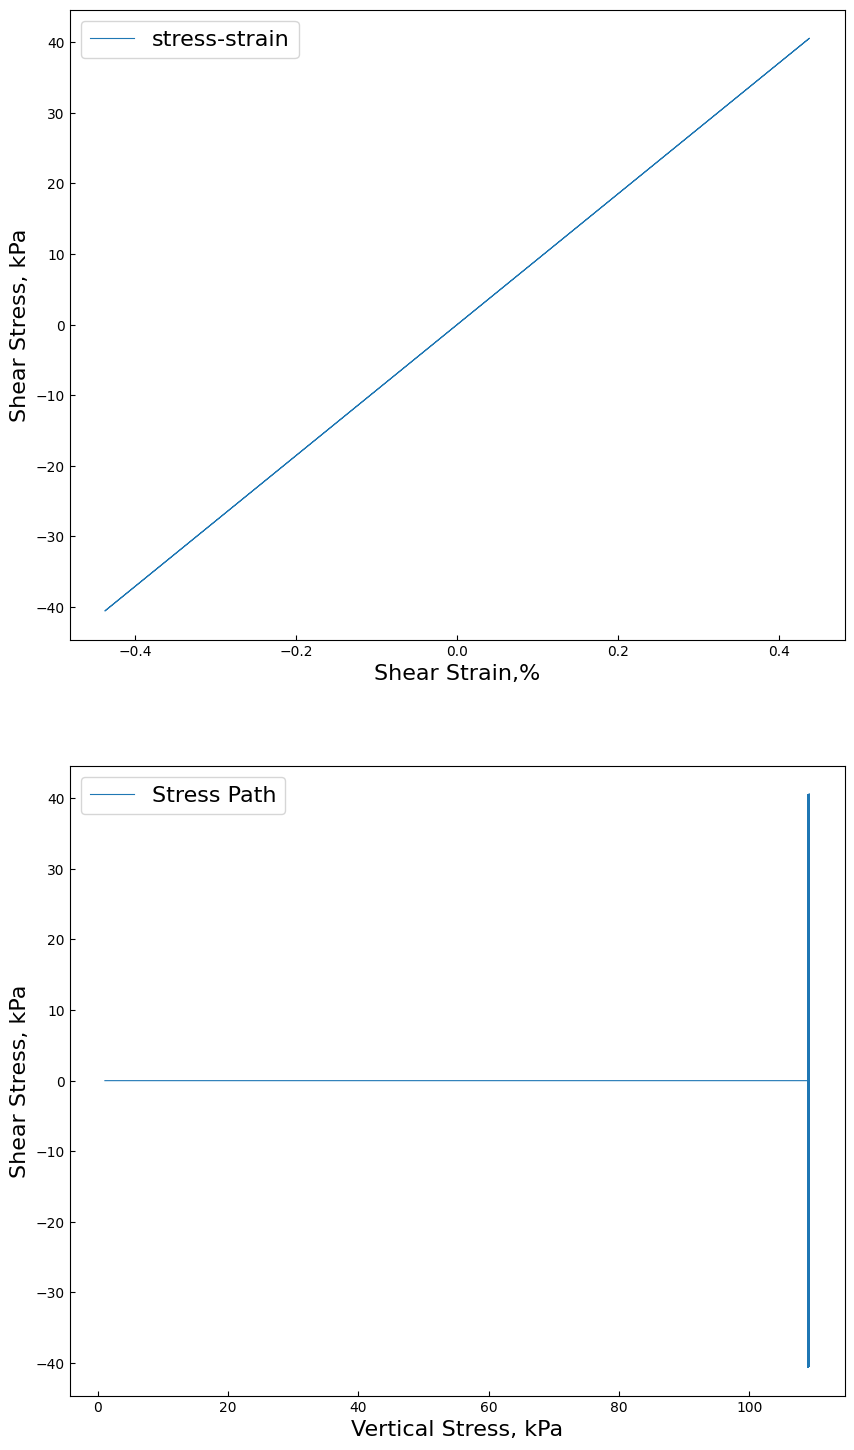

In [9]:
ops.wipe()
print('Analysis is done!')
end = tt.time()
run_time = end-start
print('Computation time is' , run_time)
#%%PostProcessing
import pandas as pd
df_stress = pd.read_csv('Cycstress.txt', sep=" ", header=None)
df_strain = pd.read_csv('Cycstrain.txt', sep=" ", header=None)
#df_PP = pd.read_csv('CycPP.txt', sep=" ", header=None)

Stress_V = df_stress.iloc[:, 1].to_numpy()*(-1.0) #compression is positive 
Shear_Stress = df_stress.iloc[:, 3].to_numpy()
Shear_Strain = df_strain.iloc[:, 3].to_numpy()*100.0

fig = plt.figure(figsize=(10,18))
ax0 = fig.add_subplot(211)
ax0.plot(Shear_Strain, Shear_Stress, label='stress-strain', linewidth=0.8)
ax0.set_xlabel("Shear Strain,%", fontsize=16)
ax0.set_ylabel("Shear Stress, kPa", fontsize=16)
ax0.legend(fontsize=16)

ax1 = fig.add_subplot(212)
ax1.plot(Stress_V, Shear_Stress, label='Stress Path', linewidth=0.8)
ax1.set_xlabel("Vertical Stress, kPa", fontsize=16)
ax1.set_ylabel("Shear Stress, kPa", fontsize=16)
ax1.legend(fontsize=16)
plt.show()
plt.close()

In [10]:
ele_resp = opst.post.get_element_responses(odb_tag=1, ele_type="Plane")

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-1.nc ...

In [11]:
print("Data Variables in Element Responses:", ele_resp.data_vars)

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 237kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 237kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 949kB 0.0 ......
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 949kB 0.0 ......
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 949kB 0.0 ......
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 949kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 316kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 316kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 1MB 0.0 ... 0.0
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 1MB 0.0 ... 0.0


In [12]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1)
sigma33 = 0
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1)
#eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)

In [13]:
print(sigma12)

<xarray.DataArray 'Stresses' (time: 19781, GaussPoints: 1)> Size: 79kB
array([[-3.8147857e-13],
       [ 6.9444448e-02],
       [ 1.1574075e-01],
       ...,
       [-1.1388928e-01],
       [-5.3433489e-02],
       [ 7.0223012e-03]], shape=(19781, 1), dtype=float32)
Coordinates:
  * time         (time) float32 79kB 0.0 151.0 152.0 ... 1.993e+04 1.993e+04
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 8B 1
    stressDOFs   <U7 28B 'sigma12'


In [14]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 19781, GaussPoints: 1)> Size: 79kB
array([[-82.8065  ],
       [ 82.83009 ],
       [ 82.83013 ],
       ...,
       [-82.83734 ],
       [-82.837296],
       [ 82.83729 ]], shape=(19781, 1), dtype=float32)
Coordinates:
  * time         (time) float32 79kB 0.0 151.0 152.0 ... 1.993e+04 1.993e+04
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 8B 1
    stressDOFs   <U7 28B 'sigma12'


In [15]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

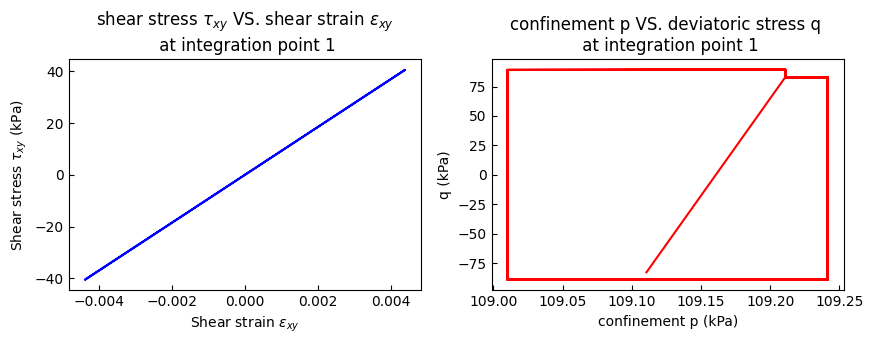

In [16]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
sigma11_ele1_1 = sigma11.sel(GaussPoints=1)
#po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-sigma11_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

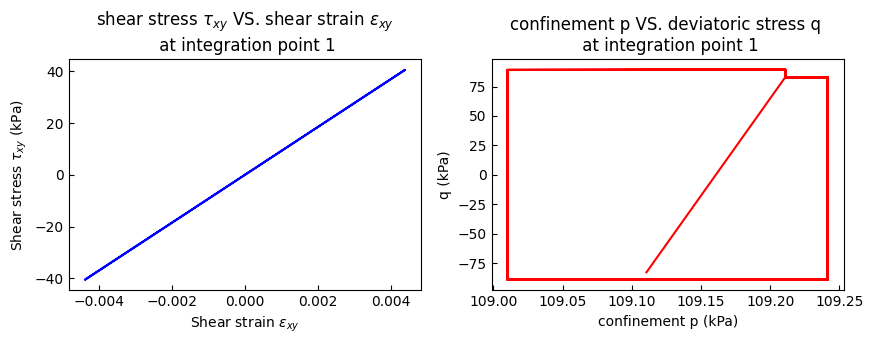

In [17]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
sigma11_ele1_1 = sigma11.sel(GaussPoints=1)
#po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-sigma11_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

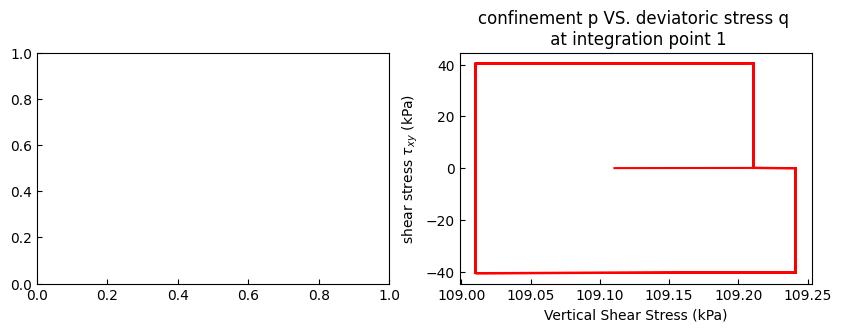

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma11, sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

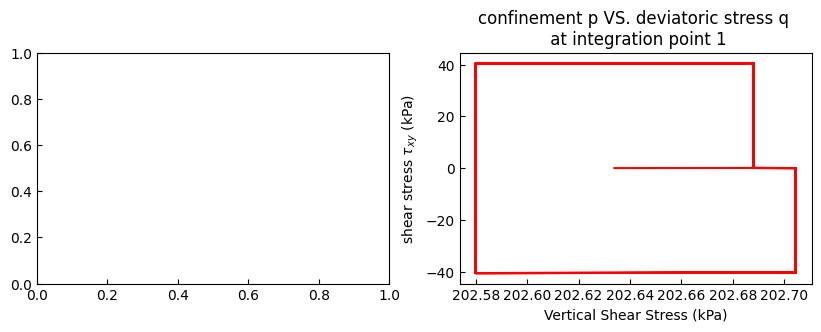

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma22, sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

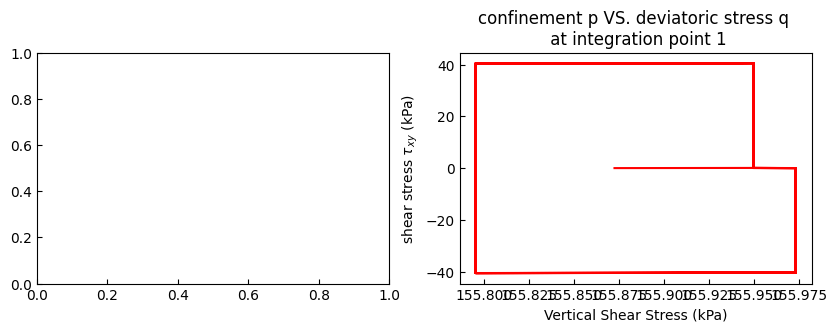

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-((sigma22+sigma11)/2), sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

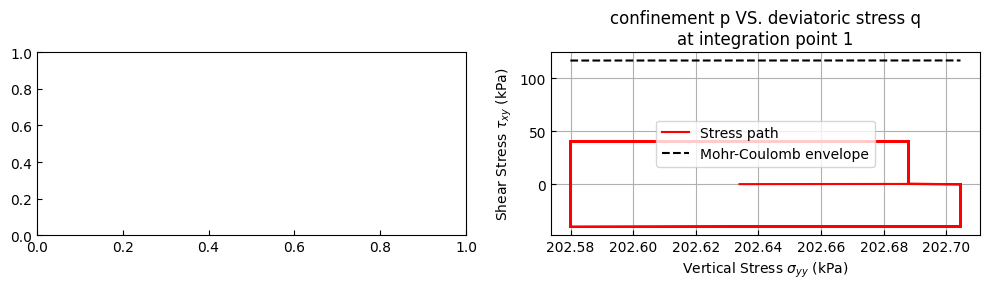

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- INPUTS ---
phi_deg = 30         # Friction angle in degrees
cohesion = 0        # Cohesion in kPa

# --- DATA (you already have these) ---
# sigma22: vertical (normal) stress
# sigma12: shear stress
# Make sure they are NumPy arrays
sigma22 = np.array(sigma22)
sigma12 = np.array(sigma12)

# --- MOHR-COULOMB FAILURE ENVELOPE ---
phi_rad = np.radians(phi_deg)
sigma_range = np.linspace(min(-sigma22), max(-sigma22), 100)
tau_failure = cohesion + sigma_range * np.tan(phi_rad)

# --- PLOTTING ---
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma22, sigma12, "r", label="Stress path")
axs[1].plot(sigma_range, tau_failure, "k--", label="Mohr-Coulomb envelope")
axs[1].set_title("confinement p VS. deviatoric stress q\nat integration point 1")
axs[1].set_xlabel("Vertical Stress $\\sigma_{yy}$ (kPa)")
axs[1].set_ylabel("Shear Stress $\\tau_{xy}$ (kPa)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


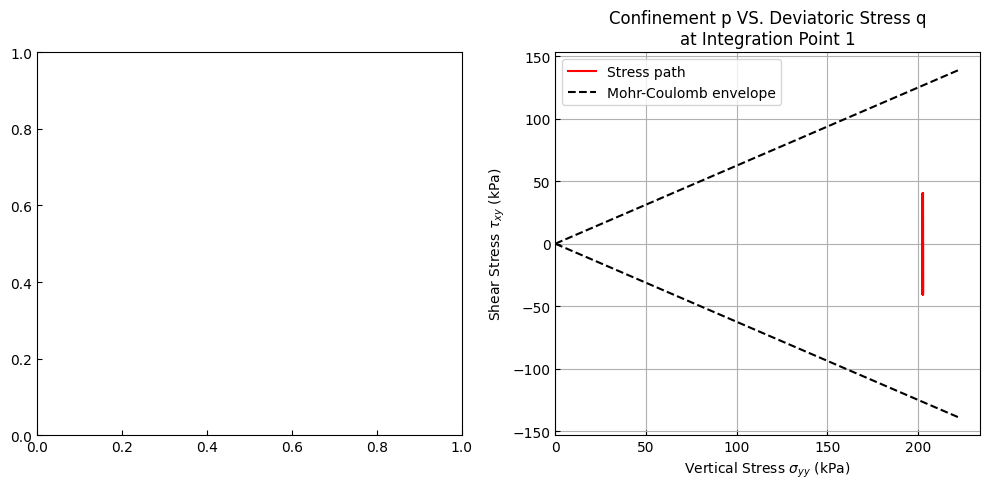

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs
phi_deg = 32          # Friction angle in degrees
cohesion = 0        # Cohesion in kPa
phi_rad = np.radians(phi_deg)

# Stress data (replace with actual values)
sigma22 = np.array(sigma22)  # Vertical normal stress
sigma12 = np.array(sigma12)  # Shear stress

# Envelope range
sigma_range = np.linspace(0, max(-sigma22) * 1.1, 200)
tau_pos = cohesion + sigma_range * np.tan(phi_rad)
tau_neg = -cohesion + sigma_range * np.tan(phi_rad)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[1].plot(-sigma22, sigma12, "r", label="Stress path")

# Mohr-Coulomb envelopes
axs[1].plot(sigma_range, tau_pos, "k--", label="Mohr-Coulomb envelope")
axs[1].plot(sigma_range, -tau_pos, "k--")  # mirrored envelope

# Labels and layout
axs[1].set_title("Confinement p VS. Deviatoric Stress q\nat Integration Point 1")
axs[1].set_xlabel("Vertical Stress $\\sigma_{yy}$ (kPa)")
axs[1].set_ylabel("Shear Stress $\\tau_{xy}$ (kPa)")
axs[1].legend()
axs[1].grid(True)
axs[1].set_xlim(left=0)
axs[1].set_ylim(
    bottom=min(-tau_pos)*1.1,
    top=max(tau_pos)*1.1
)

plt.tight_layout()
plt.show()
